## Introduction

In this tutorial, we will build a character-level text autocomplete model using a Recurrent Neural Network (RNN) in PyTorch. We will train the model on the text from "warandpeace.txt". This project will help you understand how RNNs can be implemented for text generation tasks and their application in building your own autocomplete model.


## Importing Necessary Libraries

In [376]:
# This is Cell #1

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import random
import re

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


## Setting Up the Device

In [377]:
# This is Cell #2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Reading and Preprocessing the Data

Now it is time to prepare our training data.


In [378]:
# This is Cell #3

def read_file(filename):
    with open(filename, "r", encoding="utf-8") as file:
        text = file.read().lower()
        # Keep only lowercase letters and standard punctuation (.,!?;:()[])
        text = re.sub(r'[^a-z.,!?;:()\[\] ]+', '', text)
    return text

sequence = read_file("warandpeace.txt")#[0:200000]


### Here we will train our model with a simple sequence

We will start by training our model with a simple sequence and repettitive sequence such as `"abcdefghijklmnopqrstuvwxyzabcdef..."`, and we will see if our RNN is capable of learning that pattern or not. This will help you easily verify if your RNN is working correctly or not.

In [379]:
# This is Cell #4

# sequence = "abcdefghijklmnopqrstuvwxyz" * 100

## Create Character Mappings

Creating character mappings is essential because RNNs require numerical input to process data. By mapping each unique character to an index and creating a reverse mapping, we convert text data into numerical sequences that the model can understand. This step allows us to encode input text for training and decode the model's output back into readable characters during text generation.



In [380]:
# This is Cell #5

#TODO: Create a list of unique characters from the text sequence
vocab = "abcdefghijklmnopqrstuvwxyz.,!?;:()[] "

#TODO: Create two dictionaries for character-index mappings that map each character in vocab to a unique index and vice versa
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = {idx: char for idx, char in enumerate(vocab)}

#TODO: Convert the entire text based data into numerical data
data = [char_to_idx[c] for c in sequence]

# print(data)

## Defining the CharDataset Class

Now we will create a custom dataset class to generate sequences and targets for training

Creating a custom `CharDataset` class is crucial because it prepares our text data into input sequences and target sequences that the RNN can learn from. By organizing the data this way, we can efficiently feed batches of sequences into the model during training, allowing it to learn the patterns of character sequences in the text.

In [381]:
# This is Cell #6

class CharDataset(Dataset):
    def __init__(self, data, sequence_length, stride, vocab_size):
        self.data = data
        self.sequence_length = sequence_length
        self.stride = stride
        self.vocab_size = vocab_size
        self.sequences = []
        self.targets = []
        
        # Create overlapping sequences with stride
        for i in range(0, len(data) - sequence_length, stride):
            self.sequences.append(data[i:i + sequence_length])
            self.targets.append(data[i + 1:i + sequence_length + 1])

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.long)
        target = torch.tensor(self.targets[idx], dtype=torch.long)
        return sequence, target
    

## Setting Hyperparameters

Now we will set our model's hyperparameters for our training process

Setting hyperparameters is important because they define the model's architecture and training behavior. They determine how the RNN processes data, learns patterns, and how quickly it converges during training. Properly chosen hyperparameters can significantly improve model performance and is a key step in training of models

Set the following hyperparameters for your model in the code cell below:
`sequence_length`, `stride`, `embedding_dim`, `hidden_size`, `num_layers`, `learning_rate`, `num_epochs`, `batch_size`, `vocab_size`.

In [382]:
# This is Cell #7

#TODO: Set your model's hyperparameters

sequence_length = 150  # Length of each input sequence
stride = 50            # Stride for creating sequences
embedding_dim = 32     # Dimension of character embeddings
hidden_size = 256      # Number of features in the hidden state of the RNN
learning_rate = 0.002  # Learning rate for the optimizer
num_epochs = 50         # Number of epochs to train
batch_size = 64        # Batch size for training
vocab_size = len(vocab)
input_size = len(vocab)
output_size = len(vocab)


After you have set your hyperparameters in the code cell above, very breifly tell what is the role of each of the hyperparameter that you have defined above.

`sequence_length`: length of the input sequence

`stride`: gap between each sample in the data sequence

`embedding_dim`: the size of a single character embedding

`hidden_size`: the size of the hidden state

`learning_rate`: the step size for a single step of gradient descent

`num_epochs`: the number of times the model trains on the training set

`batch_size`: number of training examples processed per step

## Splitting Data into Training and Testing Sets

By now at this point in class, I'm confident that you know why we do this, so I'm not gonna say a lot here, let's jump right into the todo.

In [383]:
# This is Cell #8


data_tensor = torch.tensor(data, dtype=torch.long).to(device)

#TODO: Convert the data into a pytorch tensor and split the data into 90:10 ratio
# train_data, test_data = train_test_split(data, test_size = 0.1, random_state=69)

# train_data = torch.tensor(train_data, dtype=torch.long).to(device)
# test_data = torch.tensor(test_data, dtype=torch.long).to(device)

dataset = CharDataset(data_tensor, sequence_length, stride, vocab_size)

train_dataset, test_dataset = train_test_split(dataset, test_size=0.1, random_state=69)


C:\Users\<redacted> <redacted>\AppData\Local\Temp\ipykernel_15540\1273917643.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence = torch.tensor(self.sequences[idx], dtype=torch.long)
C:\Users\<redacted> <redacted>\AppData\Local\Temp\ipykernel_15540\1273917643.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(self.targets[idx], dtype=torch.long)


## Creating Data Loaders

Now we will create data loaders for easy batching during training and testing.

Creating data loaders is essential to batch the data during training and testing. Batching allows the RNN to process multiple sequences in parallel, which speeds up training and makes better use of computational resources. 
We will also use Data loaders to shuffle the batched data, which is important for training models that generalize well.

Make sure to set `drop_last=True`

In [384]:
# This is Cell #9


#TODO: Initialize the training and testing data loader with batching and shuffling equal to True for training (and shuffling = False for testing)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

total_batches = len(train_loader)


## Defining the RNN Model

Here we will define our character-level RNN model.

In [385]:
# This is Cell #10

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, embedding_dim=30):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = torch.nn.Embedding(output_size, embedding_dim)
        self.W_e = nn.Parameter(torch.randn(hidden_size, embedding_dim) * 0.01)  # Smaller std
        self.b_e = nn.Parameter(torch.zeros(hidden_size))
        self.W_h = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)  # Smaller std
        self.b_h = nn.Parameter(torch.zeros(hidden_size)) 
        #TODO: set the fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax()

    def forward(self, x, hidden):
        """
        x in [b, l] # b is batch_size and l is sequence length
        """
        x_embed = self.embedding(x)  # [b=batch_size, l=sequence_length, e=embedding_dim]
        b, l, _ = x_embed.size()
        x_embed = x_embed.transpose(0, 1) # [l, b, e]
        if hidden is None:
            h_t_minus_1 = self.init_hidden(b)
        else:
            h_t_minus_1 = hidden
        output = []
        for t in range(l):
            # RNN equation from the lecture 
            # We add a bias as well to expand the range of learnable functions
            embed = x_embed[t] @ self.W_e.T + self.b_e
            hidden = h_t_minus_1 @ self.W_h.T + self.b_h
            
            h_t = torch.tanh(embed + hidden) # [b, h]
            output.append(h_t)
            h_t_minus_1 = h_t
        output = torch.stack(output) # [l, b, h]
        output = output.transpose(0, 1) # [b, l, h]

        # output shape [64, 200, 8]
        # print("output dim", output.shape) 
        final_hidden = h_t.clone() # [b, h]

        #error 12800 x 8 and 4 x 64
        logits = self.fc(output) # [b, l, vocab_size=v]
        # logits = self.softmax(logits)
        return logits, final_hidden
    
    def init_hidden(self, batch_size):
        return torch.zeros(batch_size, self.hidden_size).to(device)


For a basic high level understanding of what is the CharRNN model that you just defined above, it consists of an embedding layer, an RNN layer, and a fully connected layer. Then embedding layer converts character indices into embeddings. Then RNN processes the embeddings and captures sequential information. Then finally the fully connected layer maps the RNN outputs to the vocabulary size for character prediction.


# Initializing the Model, Loss Function, and Optimizer

Now we will create an instance of the model that we just defined above and set up the loss function and optimizer. Then we will define a loss function, that evaluates the model's prediction against the true targets, and attaches a cost (number) on how good/bad the model is doing. During our training process, it is this cost that we try to minimize by tweaking the weights of the network. 

Then we will set up an optimizer, which will update the model's parameters based on the loss returned by the our loss function. This is how our model will learn over time.


In [386]:
# This is Cell #12

#TODO: Initialize your RNN model
model = CharRNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size, embedding_dim=embedding_dim).to(device)

#TODO: Define the loss function (use cross entropy loss)
criterion = nn.CrossEntropyLoss()

#TODO: Initialize your optimizer passing your model parameters and training hyperparameters
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


## Training the Model

Now finally, after all the setup that we have done, we can train our RNN. 

A basic idea high level idea of what we will do here is we will loop over epochs and batches to train the model. 
We will Initialize the hidden state at the beginning of each epoch. For each batch, we will reset the gradients, perform a forward pass, compute the loss, perform backpropagation, and update the model parameters. Then we detach the hidden state to prevent gradients from backpropagating through previous batches. We ill repeat this process for each batch. And finally we will calculate the average loss and accuracy for each epoch.
By performing forward and backward passes, calculating loss, and updating the model parameters, we enable the RNN to improve its predictions with each epoch.

Epoch 1/50: 100%|██████████| 875/875 [00:46<00:00, 18.75it/s]


Epoch [1/50], Loss: 1.8277, Accuracy: 46.75%


Epoch 2/50: 100%|██████████| 875/875 [00:48<00:00, 18.12it/s]


Epoch [2/50], Loss: 1.4913, Accuracy: 55.94%


Epoch 3/50: 100%|██████████| 875/875 [00:48<00:00, 18.03it/s]


Epoch [3/50], Loss: 1.4310, Accuracy: 57.54%


Epoch 4/50: 100%|██████████| 875/875 [00:49<00:00, 17.82it/s]


Epoch [4/50], Loss: 1.4039, Accuracy: 58.27%


Epoch 5/50: 100%|██████████| 875/875 [00:48<00:00, 18.05it/s]


Epoch [5/50], Loss: 1.3879, Accuracy: 58.69%


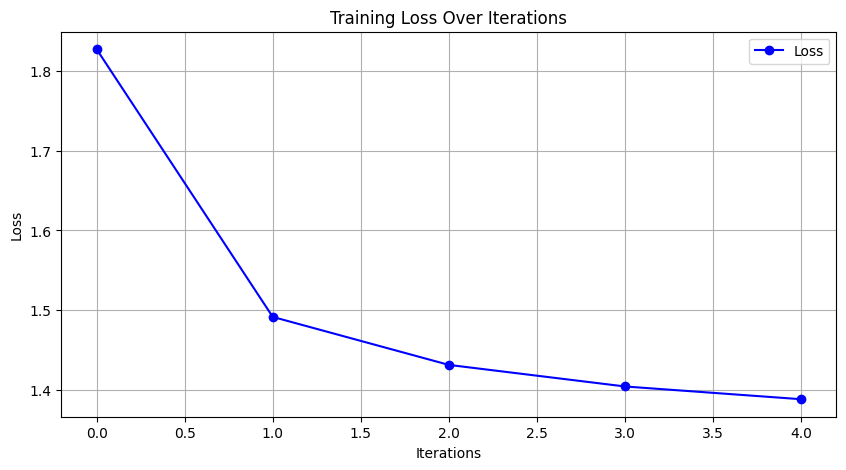

Epoch 6/50: 100%|██████████| 875/875 [00:49<00:00, 17.71it/s]


Epoch [6/50], Loss: 1.3771, Accuracy: 58.96%


Epoch 7/50: 100%|██████████| 875/875 [00:48<00:00, 17.98it/s]


Epoch [7/50], Loss: 1.3695, Accuracy: 59.17%


Epoch 8/50: 100%|██████████| 875/875 [00:48<00:00, 17.91it/s]


Epoch [8/50], Loss: 1.3640, Accuracy: 59.32%


Epoch 9/50: 100%|██████████| 875/875 [00:48<00:00, 18.06it/s]


Epoch [9/50], Loss: 1.3596, Accuracy: 59.44%


Epoch 10/50: 100%|██████████| 875/875 [00:49<00:00, 17.66it/s]


Epoch [10/50], Loss: 1.3562, Accuracy: 59.53%


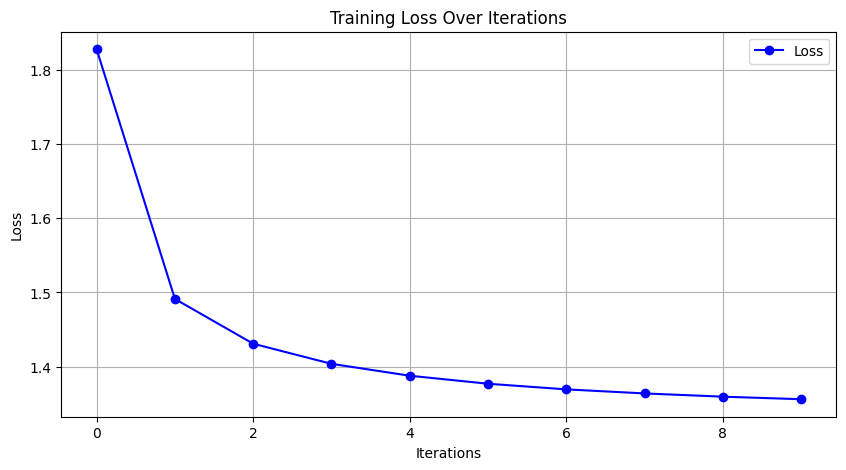

Epoch 11/50: 100%|██████████| 875/875 [00:48<00:00, 17.90it/s]


Epoch [11/50], Loss: 1.3533, Accuracy: 59.61%


Epoch 12/50: 100%|██████████| 875/875 [00:49<00:00, 17.80it/s]


Epoch [12/50], Loss: 1.3509, Accuracy: 59.66%


Epoch 13/50: 100%|██████████| 875/875 [00:48<00:00, 17.86it/s]


Epoch [13/50], Loss: 1.3490, Accuracy: 59.72%


Epoch 14/50: 100%|██████████| 875/875 [00:49<00:00, 17.75it/s]


Epoch [14/50], Loss: 1.3472, Accuracy: 59.75%


Epoch 15/50: 100%|██████████| 875/875 [00:48<00:00, 17.93it/s]


Epoch [15/50], Loss: 1.3459, Accuracy: 59.78%


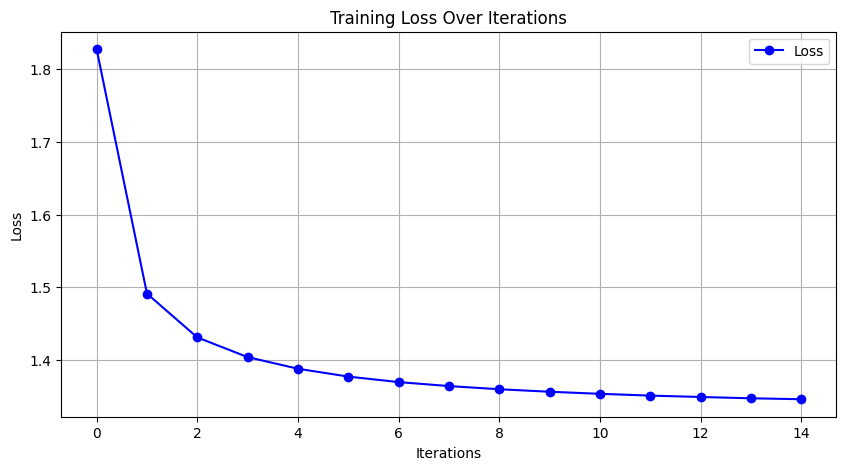

Epoch 16/50: 100%|██████████| 875/875 [00:48<00:00, 17.91it/s]


Epoch [16/50], Loss: 1.3445, Accuracy: 59.83%


Epoch 17/50: 100%|██████████| 875/875 [00:49<00:00, 17.79it/s]


Epoch [17/50], Loss: 1.3435, Accuracy: 59.85%


Epoch 18/50: 100%|██████████| 875/875 [00:49<00:00, 17.74it/s]


Epoch [18/50], Loss: 1.3427, Accuracy: 59.86%


Epoch 19/50: 100%|██████████| 875/875 [00:49<00:00, 17.68it/s]


Epoch [19/50], Loss: 1.3416, Accuracy: 59.89%


Epoch 20/50: 100%|██████████| 875/875 [00:48<00:00, 17.91it/s]


Epoch [20/50], Loss: 1.3410, Accuracy: 59.92%


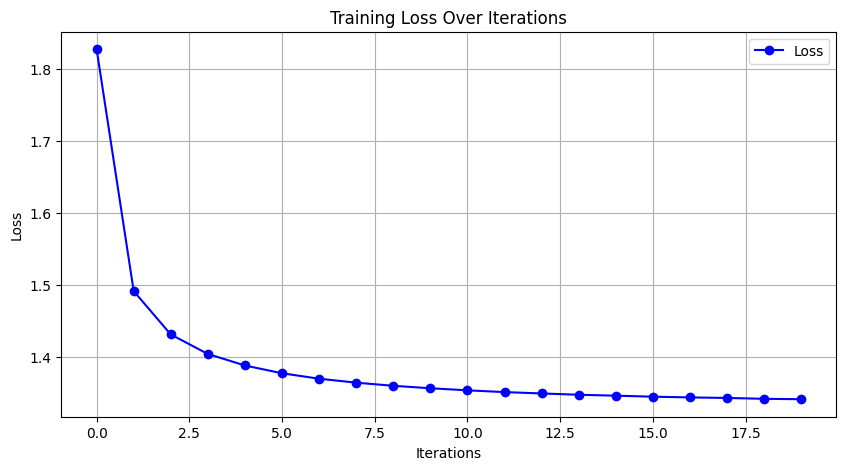

Epoch 21/50: 100%|██████████| 875/875 [00:49<00:00, 17.64it/s]


Epoch [21/50], Loss: 1.3401, Accuracy: 59.93%


Epoch 22/50: 100%|██████████| 875/875 [00:49<00:00, 17.83it/s]


Epoch [22/50], Loss: 1.3396, Accuracy: 59.95%


Epoch 23/50: 100%|██████████| 875/875 [00:49<00:00, 17.80it/s]


Epoch [23/50], Loss: 1.3390, Accuracy: 59.97%


Epoch 24/50: 100%|██████████| 875/875 [00:49<00:00, 17.76it/s]


Epoch [24/50], Loss: 1.3385, Accuracy: 59.97%


Epoch 25/50: 100%|██████████| 875/875 [00:49<00:00, 17.64it/s]


Epoch [25/50], Loss: 1.3377, Accuracy: 59.99%


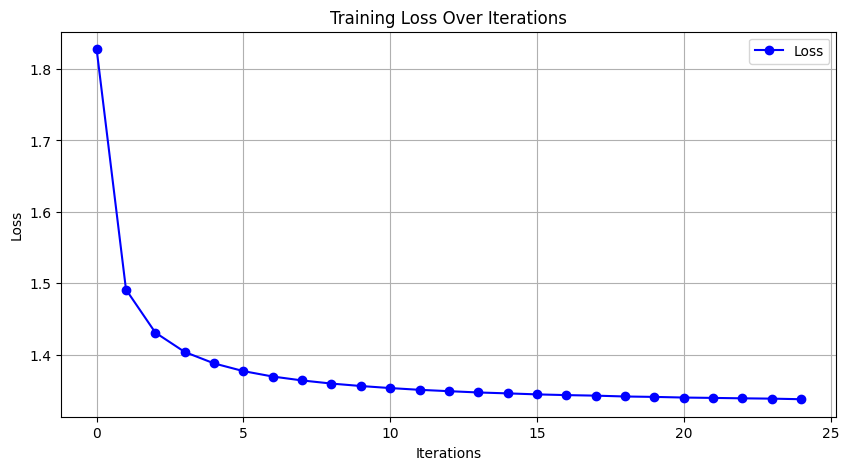

Epoch 26/50: 100%|██████████| 875/875 [00:48<00:00, 17.89it/s]


Epoch [26/50], Loss: 1.3376, Accuracy: 59.98%


Epoch 27/50: 100%|██████████| 875/875 [00:49<00:00, 17.71it/s]


Epoch [27/50], Loss: 1.3371, Accuracy: 60.01%


Epoch 28/50: 100%|██████████| 875/875 [00:48<00:00, 17.91it/s]


Epoch [28/50], Loss: 1.3367, Accuracy: 60.01%


Epoch 29/50: 100%|██████████| 875/875 [00:49<00:00, 17.60it/s]


Epoch [29/50], Loss: 1.3360, Accuracy: 60.03%


Epoch 30/50: 100%|██████████| 875/875 [00:49<00:00, 17.79it/s]


Epoch [30/50], Loss: 1.3362, Accuracy: 60.02%


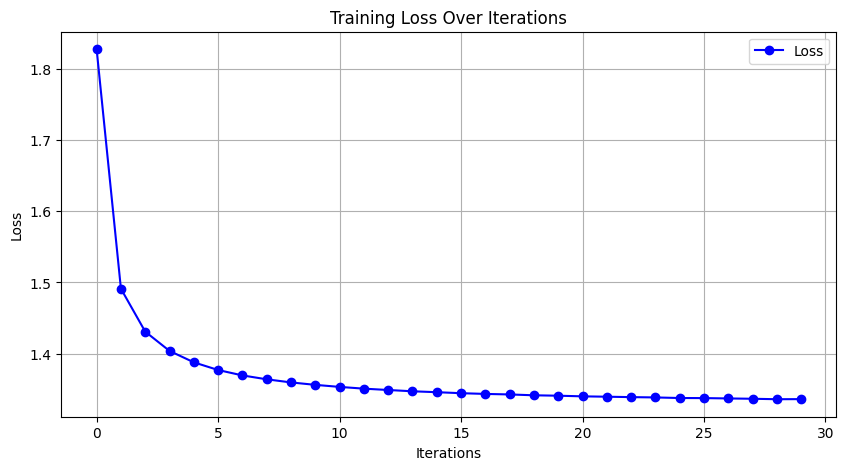

Epoch 31/50: 100%|██████████| 875/875 [00:49<00:00, 17.54it/s]


Epoch [31/50], Loss: 1.3357, Accuracy: 60.03%


Epoch 32/50: 100%|██████████| 875/875 [00:49<00:00, 17.77it/s]


Epoch [32/50], Loss: 1.3356, Accuracy: 60.03%


Epoch 33/50: 100%|██████████| 875/875 [00:49<00:00, 17.63it/s]


Epoch [33/50], Loss: 1.3355, Accuracy: 60.04%


Epoch 34/50: 100%|██████████| 875/875 [00:49<00:00, 17.78it/s]


Epoch [34/50], Loss: 1.3350, Accuracy: 60.05%


Epoch 35/50: 100%|██████████| 875/875 [00:49<00:00, 17.67it/s]


Epoch [35/50], Loss: 1.3348, Accuracy: 60.04%


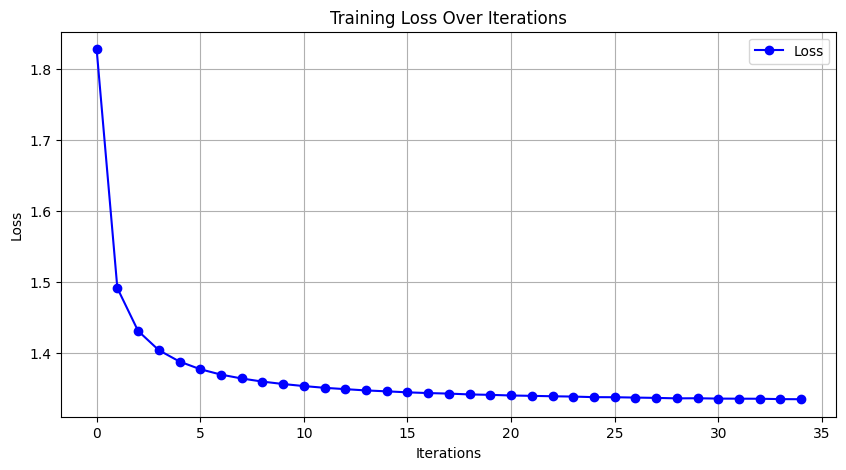

Epoch 36/50: 100%|██████████| 875/875 [00:49<00:00, 17.58it/s]


Epoch [36/50], Loss: 1.3346, Accuracy: 60.04%


Epoch 37/50: 100%|██████████| 875/875 [00:49<00:00, 17.70it/s]


Epoch [37/50], Loss: 1.3342, Accuracy: 60.05%


Epoch 38/50: 100%|██████████| 875/875 [00:49<00:00, 17.52it/s]


Epoch [38/50], Loss: 1.3342, Accuracy: 60.06%


Epoch 39/50: 100%|██████████| 875/875 [00:48<00:00, 17.87it/s]


Epoch [39/50], Loss: 1.3340, Accuracy: 60.06%


Epoch 40/50: 100%|██████████| 875/875 [00:49<00:00, 17.70it/s]


Epoch [40/50], Loss: 1.3339, Accuracy: 60.06%


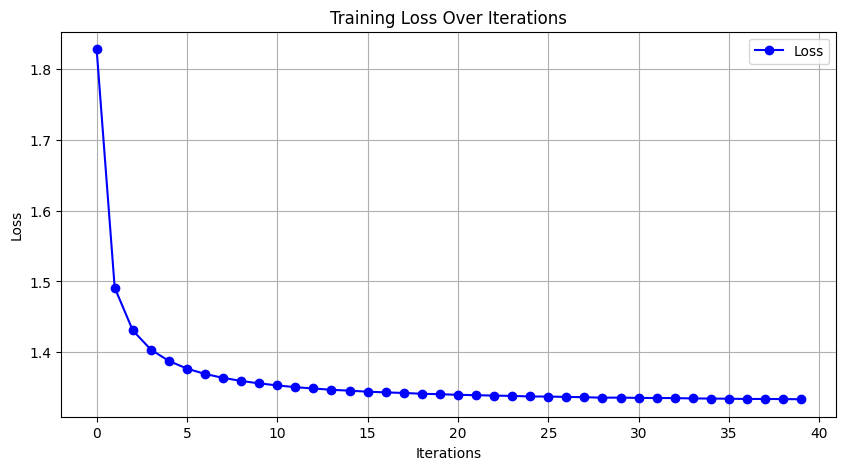

Epoch 41/50: 100%|██████████| 875/875 [00:48<00:00, 17.94it/s]


Epoch [41/50], Loss: 1.3335, Accuracy: 60.08%


Epoch 42/50: 100%|██████████| 875/875 [00:49<00:00, 17.77it/s]


Epoch [42/50], Loss: 1.3335, Accuracy: 60.07%


Epoch 43/50: 100%|██████████| 875/875 [00:48<00:00, 17.95it/s]


Epoch [43/50], Loss: 1.3335, Accuracy: 60.08%


Epoch 44/50: 100%|██████████| 875/875 [00:49<00:00, 17.66it/s]


Epoch [44/50], Loss: 1.3334, Accuracy: 60.08%


Epoch 45/50: 100%|██████████| 875/875 [00:48<00:00, 17.88it/s]


Epoch [45/50], Loss: 1.3330, Accuracy: 60.08%


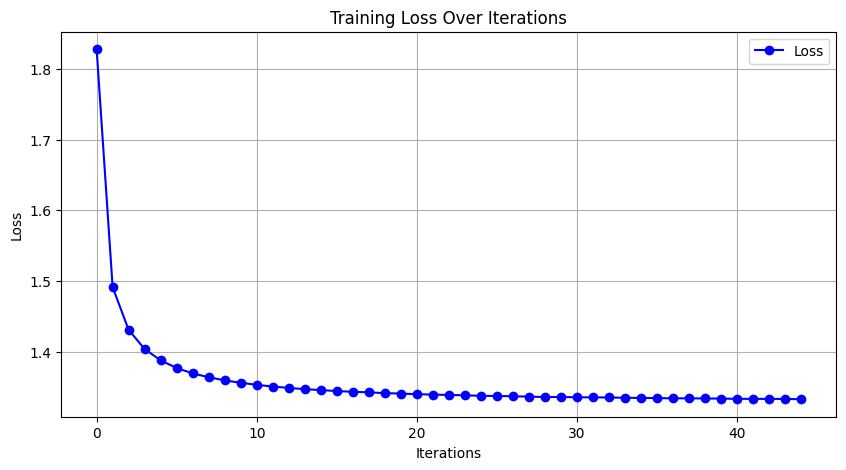

Epoch 46/50: 100%|██████████| 875/875 [00:49<00:00, 17.85it/s]


Epoch [46/50], Loss: 1.3331, Accuracy: 60.07%


Epoch 47/50: 100%|██████████| 875/875 [00:49<00:00, 17.82it/s]


Epoch [47/50], Loss: 1.3326, Accuracy: 60.08%


Epoch 48/50: 100%|██████████| 875/875 [00:49<00:00, 17.68it/s]


Epoch [48/50], Loss: 1.3327, Accuracy: 60.09%


Epoch 49/50: 100%|██████████| 875/875 [00:48<00:00, 17.91it/s]


Epoch [49/50], Loss: 1.3329, Accuracy: 60.08%


Epoch 50/50: 100%|██████████| 875/875 [00:49<00:00, 17.72it/s]

Epoch [50/50], Loss: 1.3323, Accuracy: 60.09%


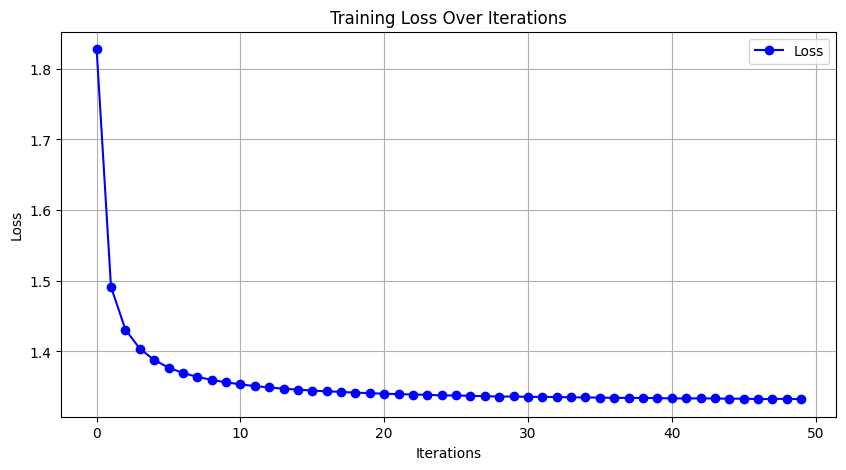

In [387]:
# This is Cell #13
losses = []

for epoch in range(num_epochs):
    total_loss, correct_predictions, total_predictions = 0, 0, 0

    hidden = model.init_hidden(batch_size)

    for batch_idx, (batch_inputs, batch_targets) in tqdm(enumerate(train_loader), total=total_batches, desc=f"Epoch {epoch+1}/{num_epochs}"):
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
        output, hidden = model(batch_inputs, None)

        hidden = hidden.detach()

        loss = criterion(output.view(-1, output_size), batch_targets.view(-1))  # Flatten the outputs and targets for CrossEntropyLoss
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        with torch.no_grad():
            # Calculate accuracy
            predicted_indices = torch.argmax(output, dim=2)  # Predicted characters
            correct_predictions += (predicted_indices == batch_targets).sum().item()
            total_predictions += batch_targets.size(0) * batch_targets.size(1)  # Total items in this batch

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions * 100  # Convert to percentage
    losses.append(avg_loss)
    # if epoch % 5 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    if epoch % 5 == 4:
        # Create a figure and axis
        plt.figure(figsize=(10, 5))

        # Plot the loss values
        plt.plot(losses, label='Loss', color='blue', marker='o')

        # Adding titles and labels
        plt.title('Training Loss Over Iterations')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()

        # Show the plot
        plt.show()

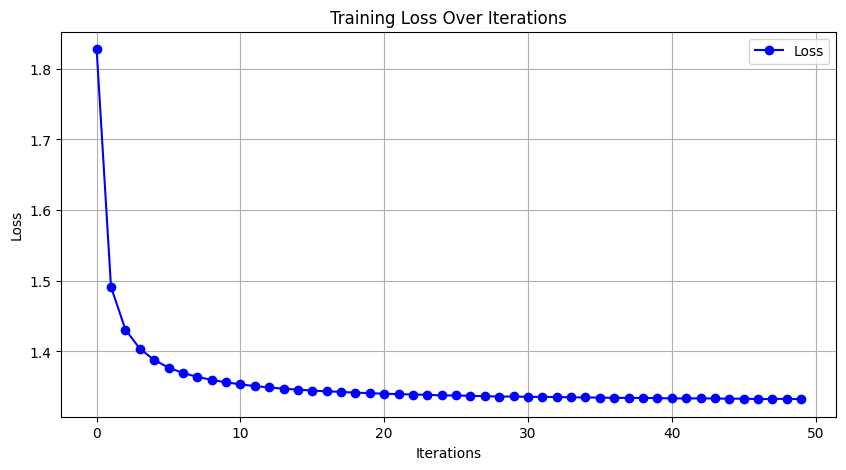

In [388]:
# Create a figure and axis
plt.figure(figsize=(10, 5))

# Plot the loss values
plt.plot(losses, label='Loss', color='blue', marker='o')

# Adding titles and labels
plt.title('Training Loss Over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()



In [389]:
#save model
torch.save(model.state_dict(), 'simple_model.pth')
print("Model saved successfully.")

Model saved successfully.


In [390]:
#load model
model = CharRNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size, embedding_dim=embedding_dim).to(device)
model.load_state_dict(torch.load('simple_model.pth'))
model.eval()

CharRNN(
  (embedding): Embedding(37, 32)
  (fc): Linear(in_features=256, out_features=37, bias=True)
  (softmax): Softmax(dim=None)
)

## Check your loss

The training loss of your model when trained with a simple sequence like `"abcdefghijklmnopqrstuvwxyz" * 100` should be extremely close to zero. If that's not the case, go back and fix your bugs ;)

If you have acheived a training loss of 0 or extremley close to 0, then congratulations, lets move on to train your model with a bit more complicated sequence. That is our old favorite book, `warandpeace.txt`.

### Read the `warandpeace.txt` file

In [391]:
# This is Cell #14

# sequence = read_file('warandpeace.txt')

### Now Follow the instructions

1. Re-run Cell #5 to re-create character mappings for `warandpeace.txt`
2. Re-run Cell #7 to re-initialize hyperparameters
3. Re-run Cell #8 to split and create training and testing data with `warandpeace.txt` as your corpus
4. Re-run Cell #9 to set up data loaders with `warandpeace.txt` data
5. Re-run Cell #12 to re-initialize a new model object (maybe ask yourself why can't you use the previous model that was trained on the simple `"abc..."` corpus)
6. Re-run Cell #13 to train the new model with `warandpeace.txt` data.
   

## Evaluating the Model

After training, we evaluate the model on the test data.

In [392]:
# This is Cell #15

with torch.no_grad():
    #TODO: Write the testing loop for your trained model by refering to the training loop code given to you above

    total_loss, correct_predictions, total_predictions = 0, 0, 0

    hidden = model.init_hidden(batch_size)

    for batch_idx, (batch_inputs, batch_targets) in tqdm(enumerate(test_loader), total=len(test_loader)):
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
        # print("batch info", batch_inputs.shape, batch_targets.shape)
        output, hidden = model(batch_inputs, None)

        hidden = hidden.detach()

        loss = criterion(output.view(-1, output_size), batch_targets.view(-1))  # Flatten the outputs and targets for CrossEntropyLoss

        # Calculate accuracy
        predicted_indices = torch.argmax(output, dim=2)  # Predicted characters

        correct_predictions += (predicted_indices == batch_targets).sum().item()
        total_predictions += batch_targets.size(0) * batch_targets.size(1)  # Total items in this batch

        total_loss += loss.item()

    avg_loss = total_loss / len(test_loader)
    accuracy = correct_predictions / total_predictions * 100  # Convert to percentage

    
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

100%|██████████| 97/97 [00:01<00:00, 55.27it/s]

Test Loss: 1.3459, Test Accuracy: 59.88%


## Generating Text with the Trained Model

In this part of the assignment, your task is to implement the `generate_text` function, which uses a trained RNN model to generate text character-by-character, continuing from a given input. The function will produce an extended sequence by repeatedly predicting and appending the next character to the input.

### What the function is supposed to do?

1. Take an initial input text of length `n` from the user, convert it into indices using a predefined vocabulary (char_to_idx).
2. Use a trained model to predict the next character in the sequence.
3. Append the predicted character to the input, extend the input sequence, and repeat the process until `k` additional characters are generated.
4. Return the generated text, including the original input and the newly predicted characters.


In [393]:
# This is Cell #16

def sample_from_output(logits, temperature=1.0):
    """
    Sample from the logits with temperature scaling.
    logits: Tensor of shape [batch_size, vocab_size] (raw scores, before softmax)
    temperature: a float controlling the randomness (higher = more random)
    """
    # Apply temperature scaling to logits (increase randomness with higher values)
    scaled_logits = logits / temperature  # Scale the logits by temperature
    # Apply softmax to convert logits to probabilities
    probabilities = F.softmax(scaled_logits, dim=1)
    
    # Sample from the probability distribution
    sampled_idx = torch.multinomial(probabilities, 1)  # Sample one index from the probability distribution
    return sampled_idx

def generate_text(model, start_text, n, k, temperature=1.0):
    """
        model: The trained RNN model used for character prediction.
        start_text: The initial string of length `n` provided by the user to start the generation.
        n: The length of the initial input sequence.
        k: The number of additional characters to generate.
        temperature: Optional
        A scaling factor for randomness in predictions. Higher values (e.g., >1) make 
            predictions more random, while lower values (e.g., <1) make predictions more deterministic.
            Default is 1.0.
    """
    start_text = start_text.lower()
    #TODO: Implement the rest of the generate_text function
    generated_text = start_text

    for i in range(k):
        seq = [char_to_idx[c] for c in generated_text[-sequence_length:]]
        seq_tensor = torch.tensor([seq], dtype=torch.int32).to(device)
        output, _ = model(seq_tensor, None)
        ind = sample_from_output(output[-1], temperature)
        generated_text += idx_to_char[ind[-1].item()]

    return generated_text

print("Training complete. Now you can generate text.")


start_text = input("Enter the initial text (n characters, or 'exit' to quit): ")

if start_text.lower() == 'exit':
    print("Exiting...")
    
else:
    n = len(start_text) 
    k = int(input("Enter the number of characters to generate: "))
    temperature_input = input("Enter the temperature value (1.0 is default, >1 is more random): ")
    temperature = float(temperature_input) if temperature_input else 1.0

    completed_text = generate_text(model, start_text, n, k, temperature)

    print(f"Generated text: {completed_text}")

Training complete. Now you can generate text.
Generated text: hello, i am bob.nicholas reaching out the horses intoo thoughtstook twhee were as a commences and second corridor. he was closes, they could not condities (mother.in restworded face which princessfust humitted back h


In [403]:
#Example text generations
print("Testing temperature")
for temp in [0.01, 0.5, 1, 1.5, 2]:
    print(f"temperature={temp}:", generate_text(model, "Once upon a", n=0, k=100, temperature=temp))

Testing temperature
temperature=0.01: once upon all the same time the same time the same time the same time the same time the same time the same time
temperature=0.5: once upon all the room when he was heard the position of the count and still such a smile, so it was a staff of
temperature=1: once upon allow without cause all sixteen massaway.so the bridge as karatures,stoom but some pantly began to. e
temperature=1.5: once upon a pauent their flank,     trlee, even, adoverhoon,have bessece, answere thei and prince not,dags lite
temperature=2: once upon about latrass ourubegt?atfrise! havin i jasowanginghold, oellvoy lazmle lop cirptc might crupprished 


## Report section

In your report, describe your experiments and observations when training the model with two datasets: (1) the sequence `"abcdefghijklmnopqrstuvwxyz" * 100` and (2) the text from `warandpeace.txt`. Include the final loss values for both datasets and discuss how the generated text differed between the two. Explain the impact of changing the `temperature` parameter on the text generation, and provide examples. Reflect on the challenges you faced, your thought process during implementation, and the key insights you gained about RNNs and sequence modeling.


The loss for sequence (1) was near 0 with 100% accuracy, while the loss for sequence (2) was about 1.33 with 60% accuracy. Debugging these models were difficult, having dealt with dimension errors, issues in the training logic, and even incorrect data split. In addition, the model's performance was barred by bad hyperparameters, such as a large learning rate or a small embedding size.  In addition, certain hyperparameters worked better on the sequence (1) compared to sequence (2), so more tuning was necessary.

Looking through the training loop, there were two things that I changed due to logical fallacy. The first was the invocation of the model: `output, hidden = model(batch_inputs, hidden)`. This model call had a persistent hidden state across all training examples, which should not be the case (each training example should be treated independently since they were shuffled). I replaced this line with `output, hidden = model(batch_inputs, None)`, which forces the model to create a default hidden state of all 0s. The second error I found was `_, predicted_indices = torch.max(output, dim=2)`. The `torch.max()` function returns the value of the maximum output, whereas we want the index of the maximum output. Although the flawed training loop seemed to get a good accuracy on sequence (1), I still corrected this line to `predicted_indices = torch.argmax(output, dim=2)`.

The final cell has some tests with different tepmeratures. When the temperature is close to 0, the result is essentially deterministic since it will almost always pick the character with the highest probability. This can result in an infinite cycle if the generation recreates a similar sequence to a previous sequence. When the temperature is more than 1, the generations sometimes stop generating real words altogether since the overall probabilities end up much more uniform. The sweet spot seems to be around temperature of 0.5 where coherent words are formed, but there is still a good amount of variation in the words.

A lesson that I picked up from this assignment was the importance of the test set. When I originally ran the training loop and test loop, I was getting accuracies like 7% or 2%. It turns out that my model was severely overfit to my incorrect training data, where the sequence was shuffled and split before the CharDataset was created. Since the training accuracies were in the 90% range, I never would have even noticed this issue if not for the test set.

Another interesting thing I noticed is that the CharDataset was designed to let the model predict a successive character for every character in the sequence, not just at the end. This likely allows the model to train much more efficiently since its essentially getting `sequence_length` training examples per single sequence.